In [1]:
import torch 
torch.cuda.is_available()

True

In [2]:
import sys
sys.path.append('../../utils')
from functions import * 

In [3]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [4]:
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal, AutoGuideList, AutoDelta, AutoMultivariateNormal
from pyro.infer import SVI, Trace_ELBO, RenyiELBO, Predictive
from pyro.distributions import constraints
import matplotlib.pyplot as plt
import math

In [5]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import load_cluster_data

import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


In [6]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    print(simple_data_junc.gene_id.unique())
    print(simple_data_junc.junction_id.unique())
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "juncratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title("cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

### Settings and Load data

In [7]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cuda
0.02


In [8]:
# this folder contains input data for each tissue cell type sample
#input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMuscle/muscle/'

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMuscle/muscle/
Finished reading in data from folder ...
['Limb_Muscle_mesenchymal_stem_cell' 'Limb_Muscle_macrophage'
 'Limb_Muscle_skeletal_muscle_satellite_cell'
 'Limb_Muscle_endothelial_cell' 'Limb_Muscle_B_cell' 'Limb_Muscle_T_cell']
1090
37197
The maximum junction count was initially:  296346
113
The maximum junction count is now:  4941
                                             cell_id  Cluster  Cluster_Counts  \
0  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      109              28   
1  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      201              13   
2  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      201              13   
3  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      333             286   
4  B4-D042186-3_8_M-1-1_Limb_Muscle_mesenchymal_s...      333             286   

             junction_id gene_id  junc_count  \
0    1_78658103_78

In [9]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
1090
1090


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [10]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,juncratio,junc_count,cluster_count,junction_id,gene_id
0,0,109,Limb_Muscle_mesenchymal_stem_cell,0,1.000000,28.0,28,1_78658103_78663140,Acsl3
1,0,201,Limb_Muscle_mesenchymal_stem_cell,1,0.307692,4.0,13,1_183316702_183318811,Aida
2,0,201,Limb_Muscle_mesenchymal_stem_cell,2,0.692308,9.0,13,1_183318934_183322283,Aida
3,0,333,Limb_Muscle_mesenchymal_stem_cell,3,0.311189,89.0,286,1_36307836_36316208,Arid5a
4,0,333,Limb_Muscle_mesenchymal_stem_cell,4,0.006993,2.0,286,1_36307836_36316211,Arid5a


In [11]:
simple_data.Cluster.unique()

array([  109,   201,   333, ..., 42815, 42827, 44869])

In [12]:
# let's visualize junction usage ratios for a given custer 
clust = 109 
#quick_clust_plot(clust, simple_data)

<Axes: xlabel='juncratio', ylabel='Density'>

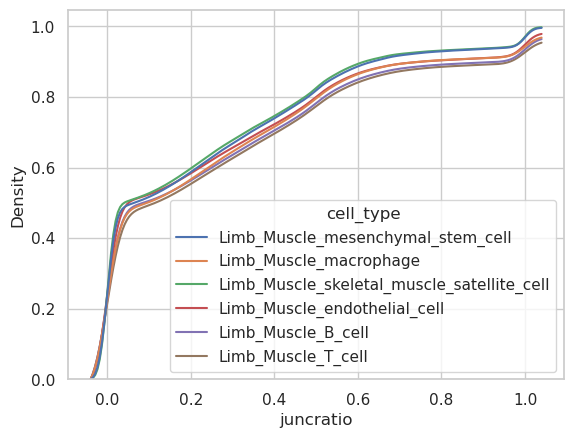

In [13]:
# use junctionratio column in final data to make histogram adn colour by cell_Type
final_data
# make density plot instead of histogram
# sns.kdeplot(data=final_data, x="juncratio", hue="cell_type", fill=True, common_norm=False, alpha=.5)
# add facet for cell_type
sns.kdeplot(data=final_data, x="juncratio", hue="cell_type", cumulative=True, common_norm=False, common_grid=True)

In [14]:
from sklearn.impute import SimpleImputer

In [15]:
# make matrix of junctions by cells and fill with juncratio values 
mat = np.zeros((len(final_data.cell_id_index.unique()), len(final_data.junction_id_index.unique())))
mat[final_data.cell_id_index, final_data.junction_id_index] = final_data.juncratio
mat[~(final_data.cell_id_index), ~(final_data.junction_id_index)] = np.nan
mat 

array([[       nan,        nan, 0.69230769, ..., 0.        , 0.        ,
        0.        ],
       [       nan, 0.        ,        nan, ..., 0.        , 0.        ,
        0.        ],
       [       nan, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [       nan, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        ,        nan, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [       nan, 0.        , 0.        , ...,        nan,        nan,
               nan]])

In [16]:
# imput nan values using mean of each row
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(mat)
mat_imputed = imp.transform(mat)
mat_imputed 
mat_imputed 

array([[0.07840685, 0.04621684, 0.69230769, ..., 0.        , 0.        ,
        0.        ],
       [0.07840685, 0.        , 0.05419053, ..., 0.        , 0.        ,
        0.        ],
       [0.07840685, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.07840685, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.04621684, 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.07840685, 0.        , 0.        , ..., 0.00102145, 0.        ,
        0.        ]])

In [17]:
# run PCA on mat_imputed 
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(mat_imputed)
pca.components_
pca.explained_variance_ratio_

array([0.04631399, 0.01667002, 0.00901791, 0.0071873 , 0.00525382,
       0.00460659, 0.00333272, 0.00285674, 0.00266468, 0.00247602])

In [18]:
# Plot PCs 
# make dataframe with PCs
pcs = pca.transform(mat_imputed)
pcs_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"])
pcs_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.474793,-1.590722,-2.720146,0.796973,1.619205,-2.077071,-0.790288,-0.670028,0.605171,-2.266783
1,18.676256,-2.388042,2.100146,3.103785,-0.430012,3.820891,2.915984,-1.148733,6.089089,14.949084
2,2.222228,-0.834902,-1.867483,-0.502695,1.104506,-1.631795,-0.460948,-0.725830,1.419466,-2.498198
3,-0.485598,-1.494257,0.212721,-1.171437,1.006132,0.808149,-0.304446,-0.658581,-0.508313,0.056124
4,4.050748,-2.309434,-2.303837,0.695266,-0.166282,-0.573624,-1.394826,-0.229238,0.288553,-2.058362


Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

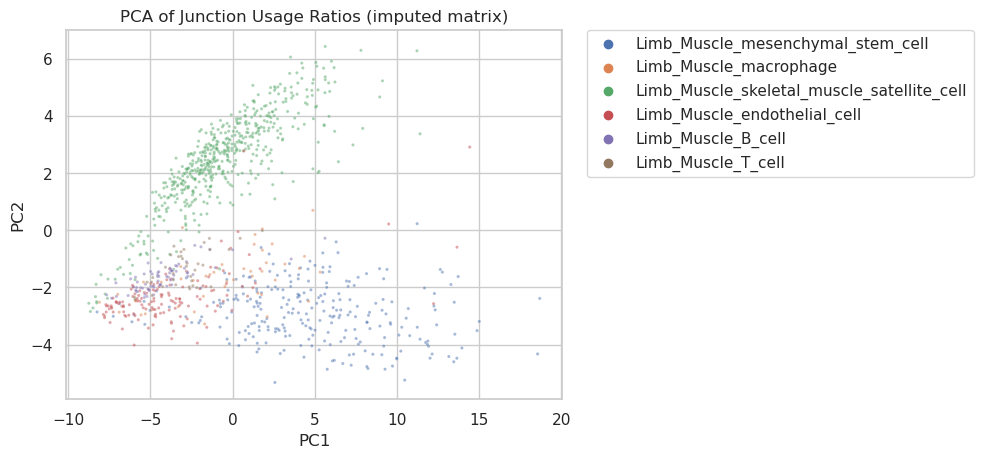

In [19]:
cell_types_pcs = cell_ids_conversion["cell_type"]
# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC1", y="PC2", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

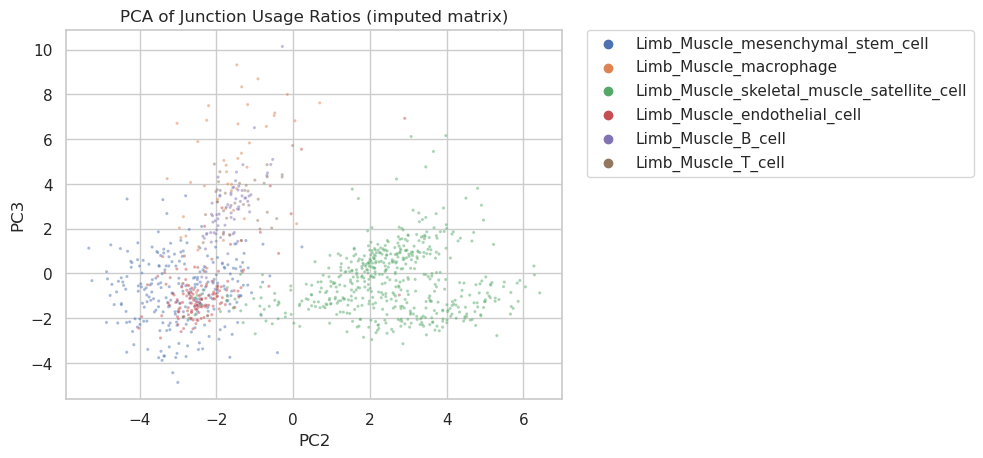

In [20]:
# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC2", y="PC3", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

Text(0.5, 1.0, 'PCA of Junction Usage Ratios (imputed matrix)')

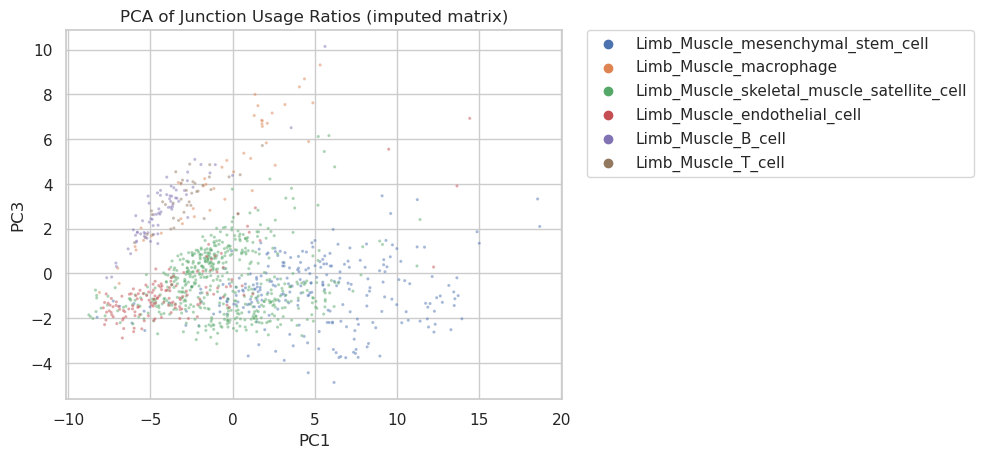

In [21]:
# plot first two PCs
sns.scatterplot(data=pcs_df, x="PC1", y="PC3", hue=cell_types_pcs.values, s=5, alpha=0.5)
# move legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Junction Usage Ratios (imputed matrix)")

In [22]:
# get total junction and cluster counts (coverage) per cell 
# plot histogram of coverage

cell_junc_cov = final_data.groupby("cell_id_index").junc_count.sum()
cell_cluster_cov = final_data.groupby("cell_id_index").cluster_count.sum()

Text(0.5, 1.0, 'Junction Coverage per Cell')

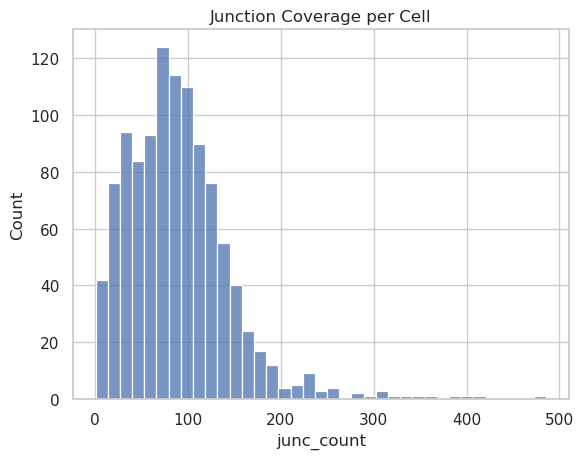

In [23]:
# plot histogram of coverage
sns.histplot(cell_junc_cov/1000)
plt.title("Junction Coverage per Cell")

Text(0.5, 1.0, 'Cluster Coverage per Cell')

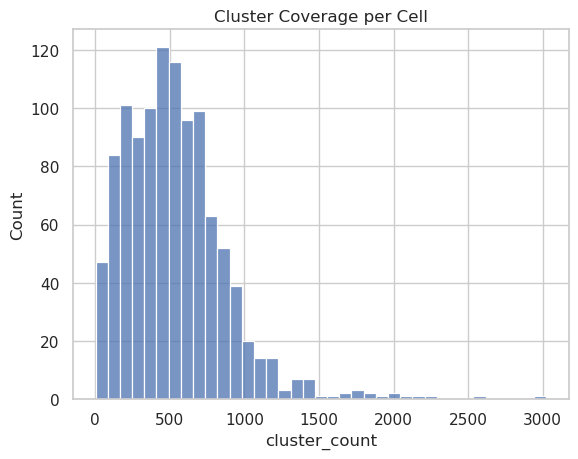

In [24]:
# plot histogram of coverage clusters 
sns.histplot(cell_cluster_cov/1000)
plt.title("Cluster Coverage per Cell")

In [25]:
def my_log_prob(y_sparse, total_counts_sparse, pred):
    
    # Extract non-zero elements and their indices from y and total_counts
    y_indices = y_sparse._indices()
    y_values = y_sparse._values()

    total_counts_indices = total_counts_sparse._indices()
    total_counts_values = total_counts_sparse._values()

    # Ensure that y and total_counts align on the same indices
    assert torch.equal(y_indices, total_counts_indices)

    # Compute log probabilities at these indices
    log_probs = dist.Binomial(total_counts_values, pred[y_indices[0], y_indices[1]]).log_prob(y_values)

    # Sum the log probabilities
    return log_probs.sum()

In [26]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

def model(y, total_counts, K):
    N, P = y.shape

    a = pyro.sample("a", dist.Gamma(1., 1.).expand([P]).to_event(1))
    b = pyro.sample("b", dist.Gamma(1., 1.).expand([P]).to_event(1))

    psi_dist = dist.Beta(a, b).expand([K, P]).to_event(2)
    psi = pyro.sample("psi", psi_dist)

    pi = pyro.sample("pi", dist.Dirichlet(torch.ones(K) / K))
    conc = pyro.sample("conc", dist.Gamma(1, 1))

    with pyro.plate('data1', N):
        assign_dist = dist.Dirichlet(pi * conc)
        assign = pyro.sample("assign", assign_dist)

    pred = torch.mm(assign, psi)

    # Use custom log probability
    log_prob = my_log_prob(y, total_counts, pred) # double check that I am not double summing here 
    pyro.factor("obs", log_prob.sum())
    #pyro.factor("obs", log_prob)

In [27]:
def fit(y, total_counts, K, guide, patience=10, min_delta=0.01, lr=0.05, num_epochs=500):
    adam = pyro.optim.Adam({"lr": lr})
    svi = SVI(model, guide, adam, loss=Trace_ELBO())
    pyro.clear_param_store()
    losses = []
    best_loss = float('inf')
    epochs_since_improvement = 0

    for j in range(num_epochs):
        loss = svi.step(y, total_counts, K)
        losses.append(loss)

        # Check for improvement
        if best_loss - loss > min_delta:
            best_loss = loss
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1

        # Early stopping check
        if epochs_since_improvement >= patience:
            print(f"Stopping early at epoch {j}")
            break

        if j % 10 == 0:
            print(f"Epoch {j}, Loss: {loss}")

        #torch.cuda.empty_cache()  # Attempt to free unused memory
    return losses

In [28]:
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [29]:
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [30]:
K = 50 # num factors
J = len(total_counts_tensor[0])
C = len(total_counts_tensor)
print(C, J, K)



1090 36016 50
AutoDiagonalNormal()


Epoch 0, Loss: 292469779.23200274
Epoch 10, Loss: 145547698.06103778
Epoch 20, Loss: 73788983.44916189
Epoch 30, Loss: 40765502.92660737
Epoch 40, Loss: 28018520.720738888
Epoch 50, Loss: 23594138.51308036
Epoch 60, Loss: 21990932.337679863
Epoch 70, Loss: 21266155.718808413
Epoch 80, Loss: 20836615.434067488
Epoch 90, Loss: 20575755.7288177
Epoch 100, Loss: 20374505.32020235
Epoch 110, Loss: 20216596.331667185
Epoch 120, Loss: 20073998.61316991
Epoch 130, Loss: 19962019.697311163
Epoch 140, Loss: 19858954.697521448
Epoch 150, Loss: 19770048.515102625
Epoch 160, Loss: 19690991.697342157
Epoch 170, Loss: 19620287.31541443
Epoch 180, Loss: 19556986.177931547
Epoch 190, Loss: 19497970.68050027


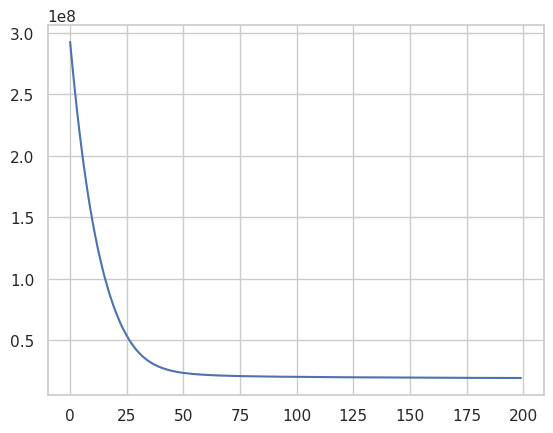

In [31]:
losses = fit(y_tensor, total_counts_tensor, K, guide, lr=0.1, num_epochs=200)
plt.plot(losses, label = "Diagonal variational posterior")

In [32]:
# Sample from the guide (posterior)
guide_trace = pyro.poutine.trace(guide).get_trace(y_tensor, total_counts_tensor, K)

In [33]:
# Extract the latent variables
latent_vars = {name: node["value"].detach().cpu().numpy() for name, node in guide_trace.nodes.items() if node["type"] == "sample"}

In [34]:
latent_vars["conc"]

array(27.984833, dtype=float32)

In [35]:
# can we plot assign probabilityies for each cell
assign_post = latent_vars["assign"]
assign_post

array([[1.34109796e-04, 9.50012326e-01, 5.45363982e-05, ...,
        1.09335969e-11, 6.90864823e-08, 3.80591425e-09],
       [4.36343071e-05, 7.34978497e-01, 3.37063648e-06, ...,
        3.65477787e-11, 3.54652330e-09, 1.15529204e-10],
       [4.11642795e-05, 9.05716181e-01, 7.78658650e-05, ...,
        6.24904122e-12, 2.98054736e-08, 4.84818963e-10],
       ...,
       [2.06456127e-04, 5.35338104e-01, 7.34386631e-05, ...,
        1.65610501e-07, 4.04206367e-06, 9.57424806e-10],
       [1.21969955e-04, 7.96150923e-01, 2.33149738e-04, ...,
        3.39360999e-13, 1.06628855e-11, 1.04934351e-13],
       [4.54031033e-05, 6.17747962e-01, 2.15532855e-04, ...,
        4.09945081e-12, 6.55831899e-12, 2.26767910e-11]], dtype=float32)

(array([52714.,   352.,   204.,   100.,    65.,    61.,   123.,   212.,
          266.,   403.]),
 array([1.63879365e-28, 9.95643884e-02, 1.99128777e-01, 2.98693150e-01,
        3.98257554e-01, 4.97821927e-01, 5.97386301e-01, 6.96950674e-01,
        7.96515107e-01, 8.96079481e-01, 9.95643854e-01]),
 <BarContainer object of 10 artists>)

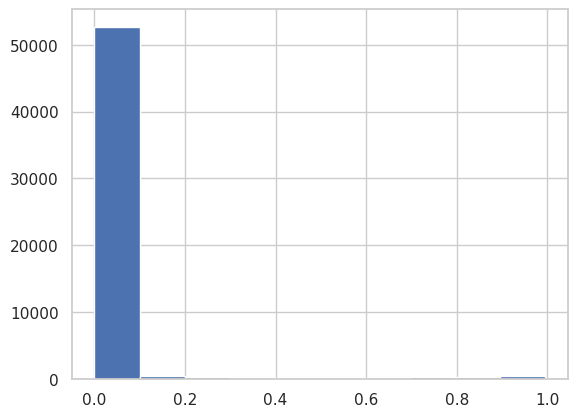

In [36]:
# make histgram of all the values in assign_post
plt.hist(assign_post.flatten(), bins=10)

In [37]:
# Run PCA on assign_post
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(assign_post)
X = pca.transform(assign_post)
X.shape

(1090, 10)

Text(0, 0.5, 'PC2')

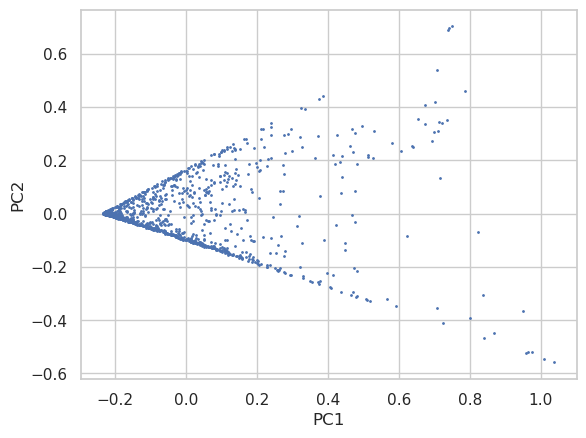

In [38]:
# plot PCA
plt.scatter(X[:, 0], X[:, 1], s=1)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [39]:
# standardize values in assign_post
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(assign_post)
assign_post_scaled = scaler.transform(assign_post)
assign_post_scaled

array([[-0.09975956,  0.7988042 , -0.08444989, ..., -0.03568543,
        -0.05087611, -0.06730797],
       [-0.23556744, -0.26929584, -0.08568075, ..., -0.03568356,
        -0.06505033, -0.07484995],
       [-0.23927505,  0.5787797 , -0.08388866, ..., -0.03568578,
        -0.05937135, -0.07409523],
       ...,
       [ 0.00883562, -1.2609348 , -0.08399516, ..., -0.02352779,
         0.8083534 , -0.07312938],
       [-0.11798202,  0.03455529, -0.08015309, ..., -0.03568622,
        -0.06581503, -0.07508584],
       [-0.23291238, -0.8515946 , -0.08057688, ..., -0.03568594,
        -0.06581592, -0.07503971]], dtype=float32)

Text(0, 0.5, 'PC2')

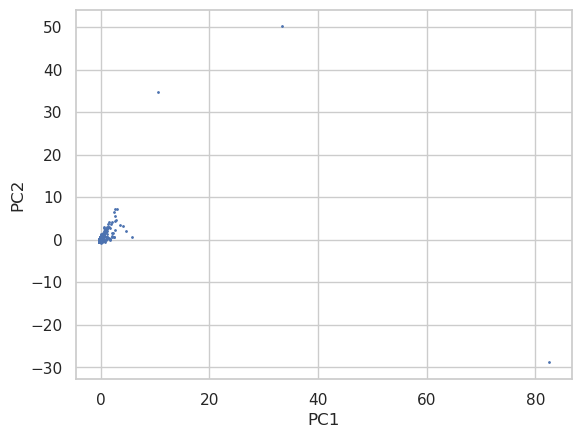

In [67]:
pca = PCA(n_components=10)
pca.fit(assign_post_scaled)
X = pca.transform(assign_post_scaled)
plt.scatter(X[:, 0], X[:, 1], s=1)
plt.xlabel("PC1")
plt.ylabel("PC2")


In [50]:
row_indices = np.where(X[:, 0] > 10)
row_indices

(array([833, 841, 842]),)

In [53]:
final_data[final_data["cell_id_index"] == 842].cluster_count.sum()

2134

In [58]:
# find row indices where values where PC1 is greater than 6
row_indices = np.where(X[:, 0] > 6)
row_indices

(array([], dtype=int64),)

In [71]:
# Step 1: Run UMAP
import umap

In [61]:
# Step 2: Prepare cell type labels for coloring
cell_types = cell_ids_conversion['cell_type'].tolist()

Limb_Muscle_skeletal_muscle_satellite_cell    540
Limb_Muscle_mesenchymal_stem_cell             258
Limb_Muscle_endothelial_cell                  141
Limb_Muscle_B_cell                             71
Limb_Muscle_macrophage                         45
Limb_Muscle_T_cell                             35
Name: cell_type, dtype: int64


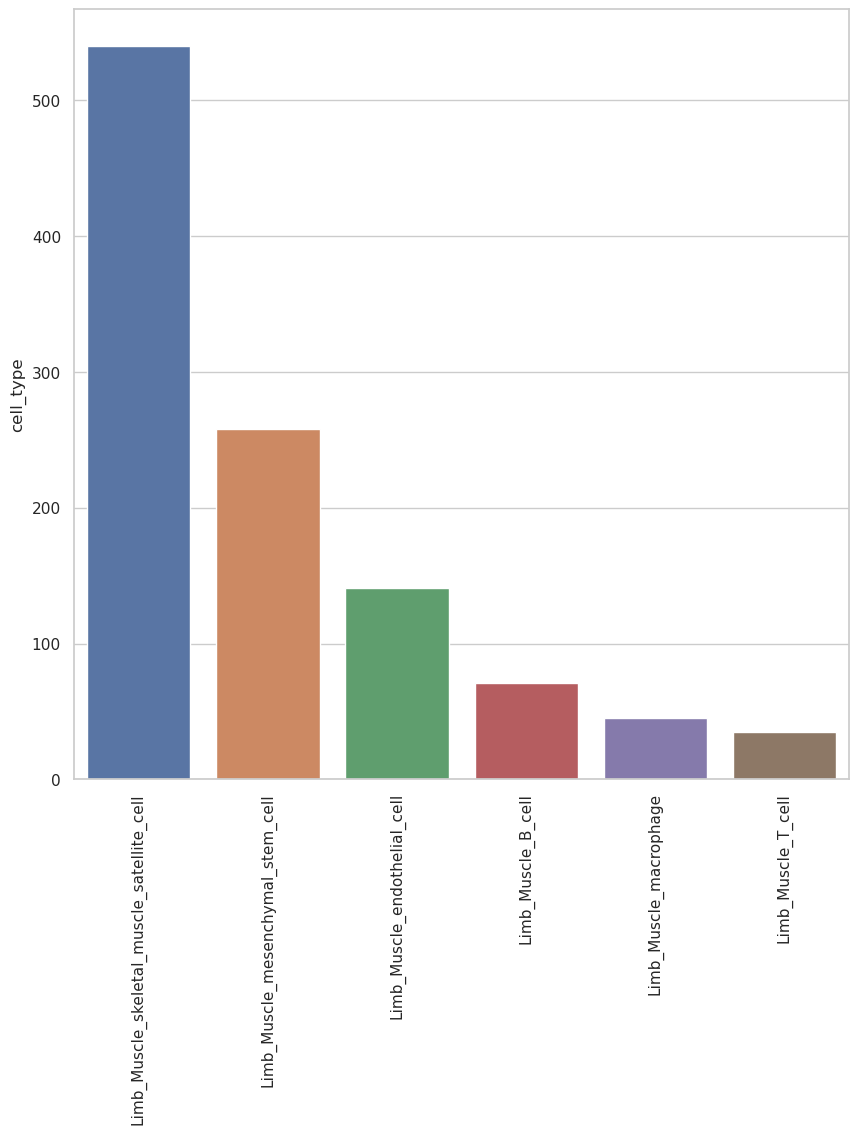

In [62]:
print(cell_ids_conversion.cell_type.value_counts())
# make a barplot of cell type counts
plt.figure(figsize=(10, 10))
sns.barplot(x = cell_ids_conversion.cell_type.value_counts().index, y = cell_ids_conversion.cell_type.value_counts())
plt.xticks(rotation=90)
plt.show()

In [63]:
top_three_cell_types = cell_ids_conversion.cell_type.value_counts()[0:5].index.values
cell_types = cell_ids_conversion['cell_type'].apply(lambda x: x if x in top_three_cell_types else 'Other').tolist()

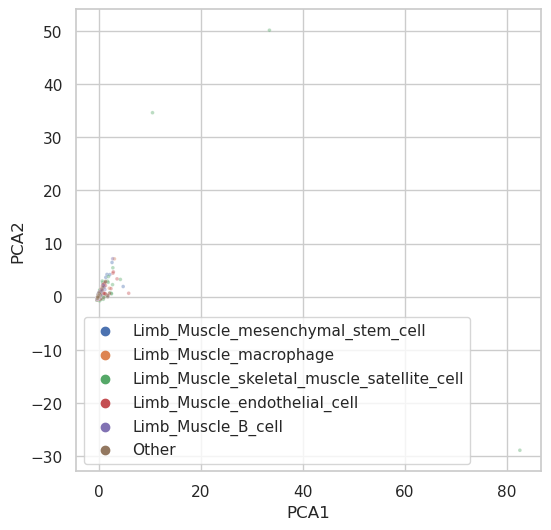

In [68]:
# plot PCA results and color by cell type using sns
plt.figure(figsize=(6, 6))
sns.scatterplot(x = X[:, 0], y= X[:, 1], hue = cell_types, s=7, alpha=0.4)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

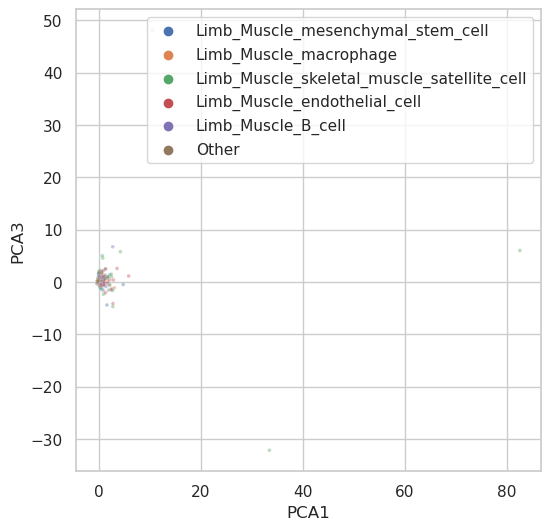

In [69]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x = X[:, 0], y= X[:, 2], hue = cell_types, s=7, alpha=0.4)
plt.xlabel("PCA1")
plt.ylabel("PCA3")
plt.show()

In [72]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post_scaled)  # Reducing to 2 dimensions

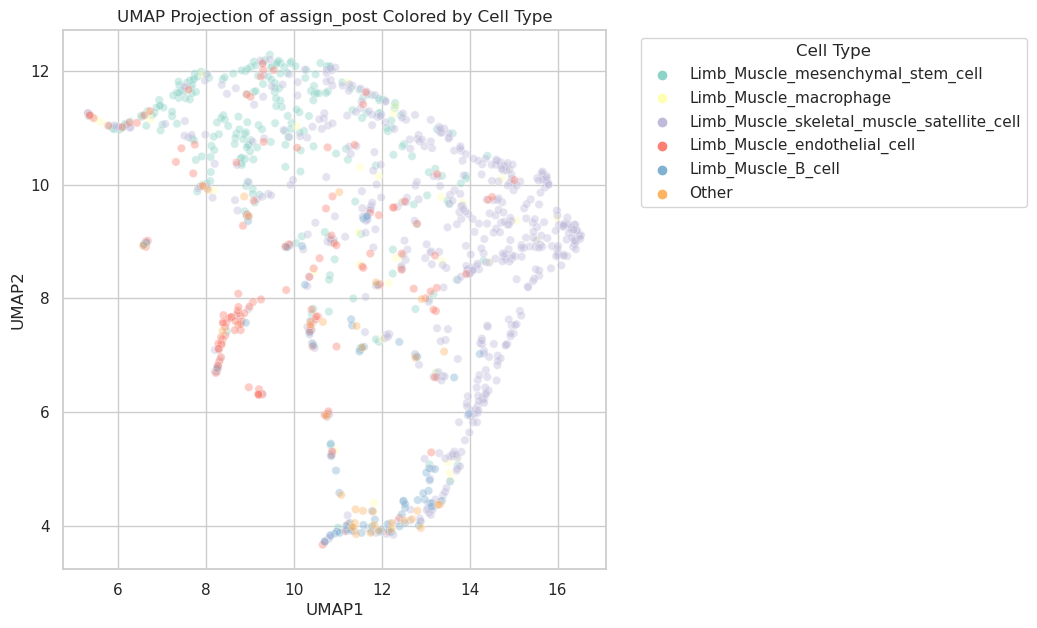

In [73]:
# Plotting
plt.figure(figsize=(7, 7))
sns.scatterplot(
    x=embedding[:, 0], 
    y=embedding[:, 1], 
    hue=cell_types,
    alpha=0.4,
    palette=sns.color_palette("Set3", len(top_three_cell_types) + 1),  # +1 for 'Other' category
    legend='full'
)
plt.title("UMAP Projection of assign_post Colored by Cell Type")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [74]:
# convert latent_vars["assign"] to pandas dataframe
assign_post_df = pd.DataFrame(assign_post)
assign_post_df.columns = ["factor_" + str(x) for x in assign_post_df.columns]   
assign_post_df.head()

,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,...,factor_40,factor_41,factor_42,factor_43,factor_44,factor_45,factor_46,factor_47,factor_48,factor_49
0,0.000134,0.950012,0.000055,0.000018,0.000047,0.000022,0.000011,0.044536,8.215678e-06,0.000002,...,3.238785e-09,1.082197e-09,4.041977e-11,5.551862e-08,1.623063e-09,2.587196e-09,3.413451e-08,1.093360e-11,6.908648e-08,3.805914e-09
1,0.000044,0.734978,0.000003,0.000039,0.000068,0.000138,0.000024,0.260519,1.843924e-07,0.000002,...,2.018466e-08,1.083922e-09,2.585014e-10,2.354647e-09,3.525580e-09,6.036271e-11,4.578092e-08,3.654778e-11,3.546523e-09,1.155292e-10
2,0.000041,0.905716,0.000078,0.000097,0.000005,0.000025,0.000162,0.087545,2.370711e-08,0.000033,...,2.371157e-09,3.403355e-11,6.120967e-10,6.796361e-09,1.687755e-11,1.246882e-09,2.344878e-11,6.249041e-12,2.980547e-08,4.848190e-10
3,0.000096,0.716671,0.001348,0.000112,0.000209,0.000025,0.000858,0.274205,3.176932e-04,0.000008,...,1.677735e-12,2.199283e-12,2.676297e-10,1.831661e-12,2.867137e-12,2.816555e-14,6.085982e-14,4.382626e-15,7.086651e-13,4.914197e-16
4,0.000220,0.911347,0.000283,0.000153,0.000002,0.000036,0.000043,0.079517,1.350956e-06,0.000002,...,4.635577e-11,4.108071e-10,1.919236e-08,4.442821e-08,6.177404e-10,6.259684e-09,9.481228e-09,2.058776e-08,1.537314e-06,2.389040e-08


In [75]:
# get factor sums column wise 
factor_sums = assign_post_df.sum(axis=0)
# order factors by sums
factor_sums.sort_values(ascending=False, inplace=True)
# get top 10 factors
top_factors = factor_sums.index[0:10]
top_factors

Index(['factor_1', 'factor_7', 'factor_10', 'factor_12', 'factor_17',
       'factor_20', 'factor_4', 'factor_2', 'factor_22', 'factor_23'],
      dtype='object')

In [76]:
latent_vars["assign"][0].max()

0.9500123

Text(0, 0.5, 'Number of Cells')

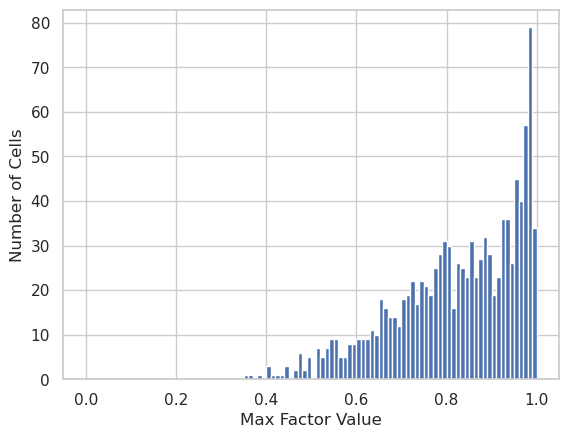

In [80]:
# get max value for every latent_vars["assign"]
max_factor = latent_vars["assign"].max(axis=1)
plt.hist(max_factor, bins=100, range=(0, 1))
# label x axis 
plt.xlabel("Max Factor Value")
plt.ylabel("Number of Cells")

Text(0.5, 1.0, 'assign_post values across ALL factors')

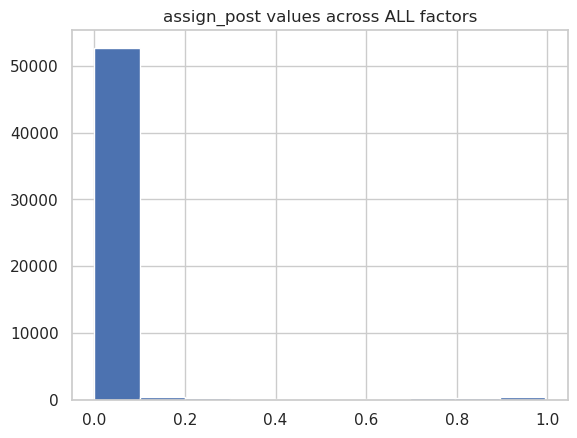

In [83]:
plt.hist(latent_vars["assign"].flatten(), bins=10)
# add title 
plt.title("assign_post values across ALL factors")

In [82]:
top_three_cell_types_list = list(top_three_cell_types)
top_three_cell_types_list

['Limb_Muscle_skeletal_muscle_satellite_cell',
 'Limb_Muscle_mesenchymal_stem_cell',
 'Limb_Muscle_endothelial_cell',
 'Limb_Muscle_B_cell',
 'Limb_Muscle_macrophage']

In [84]:
# Create a color palette for the cell types
cell_type_palette = sns.color_palette("hsv", len(top_three_cell_types_list) + 1)

# Map cell types to colors
row_colors = [cell_type_palette[top_three_cell_types_list.index(ct)] if ct in top_three_cell_types_list else cell_type_palette[-1] for ct in cell_types]

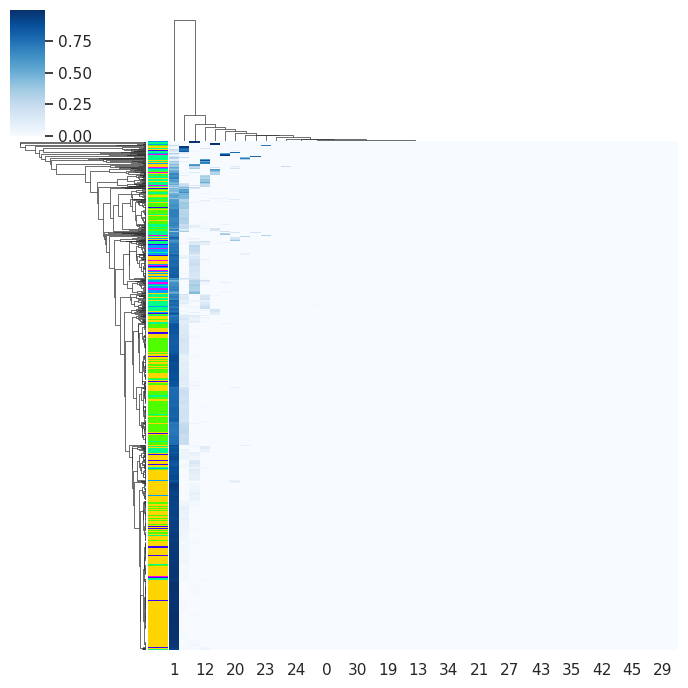

In [85]:
# Generate the clustermap with row colors
sns.clustermap(assign_post, cmap="Blues", figsize=(7, 7),
              row_colors=row_colors,  # Using a list instead of a DataFrame
               yticklabels=False)  # Hide y-axis labels for clarity

plt.show()

In [86]:
# compare to autoencoder (within pyro?) ?Sophia? 
# VAE in pyro afterwards... (with a binomial loss on the end) along the lines of this model 
# run original code on simulated data and compare to current code 

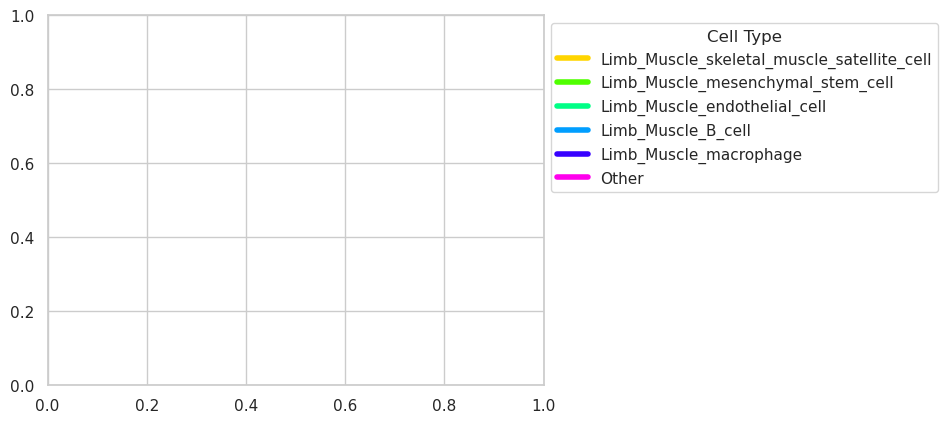

In [87]:
# Create a custom legend for the cell types
# Here, we use the cell_type_palette and top_three_cell_types
legend_handles = [plt.Line2D([0], [0], color=color, lw=4) for color in cell_type_palette]
legend_labels = top_three_cell_types_list + ['Other']

# Add the legend to the plot
plt.legend(handles=legend_handles, labels=legend_labels, title='Cell Type',
           bbox_to_anchor=(1, 1), loc='upper left')